# Dissertation results
This section consolidates all the notebook cells that were used in the making of the figures and tables used in the COMP3000 dissertation.

In [1]:
# %pip install torch torchvision opencv-python numpy pandas gradio matplotlib scikit-learn

In [2]:
import os, sys, json, math
from pathlib import Path

import numpy as np
import cv2
import torch
import torch.nn as nn
import torchvision.transforms as T
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.abspath("."))
print("The working directory is:", os.getcwd())

HAS_CATFLW = (
    Path("data/images").exists()
    and Path("data/labels").exists()
    and any(Path("data/labels").glob("*.json"))
)

print("CatFLW available:", HAS_CATFLW)

from src.tools import find_matching_image
from src.facial_landmark_labeller import LANDMARK_INDEX_MAP
from src.computations import compute_all_features, EVANGELISTA_STATS
from src.pain_classifier import classify_landmarks

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:",device)

LABEL_DIR = Path("data/labels")

if HAS_CATFLW: 
    from src.cat_cnn import(
        get_model, CatLandmarksDataset, make_split_indices,
        image_dir, label_dir, all_label_files, num_landmarks,
        train_indices, val_indices, test_indices, batch_size,
    )

    from src.nme import evaluate_nme, print_nme_report, EAR_INDICES, EYE_INDICES

    print(f"splits - train: {len(train_indices)}, val:{len(val_indices)}, test:{len(test_indices)}")

    train_files = [all_label_files[i] for i in train_indices]
    test_files = [all_label_files[i] for i in test_indices]

    assert not (set(train_files) & set(test_files)), "train/test overlap - serious problem found"
    print("splits disjoint")

else:
    print(
        "Cat FLW labels were not found in data/labels so dataset dependent checks were skipped.\n"
        "This includes the split disjointness checks and NME evaluation.\n"
        "To run these cells download CatFLW and place JSON labels in data/labels/ and images in data/images/."
    )

The working directory is: c:\Users\marro\OneDrive\Desktop\comp3000\comp3000-marie
CatFLW available: True
device: cuda
CUDA is working! GPU being used: NVIDIA GeForce RTX 4060 Laptop GPU
splits - train: 1455, val:311, test:313
splits disjoint


In [3]:
def load_trained(model_name):
    if not HAS_CATFLW:
        raise RuntimeError(
            "Cannot load model for CatFLW eval because setup was skipped."
        )
    m = get_model(model_name, num_landmarks, pretrained=False).to(device)
    path = os.path.join(".", f"cat_model_{model_name}.pt")
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    return m

ARCHS = ["resnet18", "resnet50", "efficientnet_b0","mobilenet_v3_small"]
BUCKETS = ["very_unlikely","unlikely","likely","very_likely"]


In [4]:
PROJECT_ROOT = Path.cwd()

PASS1_PATH = PROJECT_ROOT / "pain_labels" / "pain_labels_pass1.json"
PASS2_PATH = PROJECT_ROOT / "pain_labels" / "pain_labels_pass2.json"
RATER2_PATH = PROJECT_ROOT / "pain_labels" / "pain_labels_rater2.json"

HIST18_PATH = PROJECT_ROOT / "training_histories" / "training_history_resnet18.json"
HIST50_PATH = PROJECT_ROOT / "training_histories" / "training_history_resnet50.json"

LABEL_TO_INT = {label: i for i, label in enumerate(BUCKETS)}


## 7.1 Landmark accuracy
Reproduces **Table 1** (5 worst predicted landmarks for ResNet-18) and **Table 2** (overall/ears/eyes NME for all four architectures).

In [ ]:
from pathlib import Path

# Evaluating NME on test split for all architectures
results_71 = {}
if not HAS_CATFLW:
    print("Skipping this cell because it requires CatFLW images/labels")
else:


    if "get_model" not in globals():
        print(""
        "Skipping NME architecture copmarison because CatFLW-dependent setup cell was not run.\n"
        "To run this cell, please place CatFLW labels in data/labels and images in data/images,\n"
        "then rerun the setup cell.")
    else:
        for arch in ARCHS:
            checkpoint_path = Path(f"cat_model_{arch}.pt")

            if not checkpoint_path.exists():
                print(
                    f"{arch:20s} checkpoint not found:  {checkpoint_path}\n"
                    f"{'':20s}  Skipping this architecture. This checkpoint is omitted from"
                    "the repo because it is not required for the Gradio demo.\n"
                    f"{'':20s} To reproduce it, retrain with "
                    f"model_name = '{arch}' and run_training = True in src/cat_cnn.py."
                )
                continue
            
            model = load_trained(arch)
            r = evaluate_nme(model, test_files, image_dir, label_dir, device)
            results_71[arch] = r
            print(f"{arch:20s}  overall={r['overall']:.2f}%  ears={r['ears']:.2f}%  eyes={r['eyes']:.2f}%")

resnet18              overall=1.27%  ears=2.06%  eyes=0.96%
resnet50              overall=1.40%  ears=2.07%  eyes=1.10%
efficientnet_b0       overall=2.28%  ears=2.54%  eyes=2.03%
mobilenet_v3_small    overall=2.33%  ears=3.15%  eyes=2.03%


In [6]:
# Table 1: 5 worst predicted landmarks for ResNet-18
if "resnet18" not in results_71:
    print(
        "Skipping as ResNet-18 NME results not computed."
    )
else:
    r = results_71["resnet18"]
    per_lm = r["per_landmark"]
    worst = np.argsort(per_lm)[::-1][:5]
    print(f"{'Landmark':30s}{'NME':>10s}")
    print("-" * 40)
    for idx in worst:
        name = LANDMARK_INDEX_MAP.get(int(idx), "(undefined)")
        print(f"{name:30s}{per_lm[idx]:>9.3f}%")

    print_nme_report(r, model_name="resnet18")

Landmark                             NME
----------------------------------------
left_ear_outer_base               2.567%
right_ear_outer_base              2.410%
left_ear_outer_middle             2.085%
right_ear_tip                     2.062%
left_ear_tip                      2.024%

NME Report for resnet18
Images evaluated: 313
Normaliser: bounding box diagonal

  Overall NME: 1.266%
  Ears NME: 2.063%   (landmarks [22, 23, 24, 25, 26, 27, 28, 29, 30, 31])
  Eyes NME: 0.955%   (landmarks [4, 5, 6, 7, 8, 9, 10, 11])
  Other NME: 1.083%

5 worst landmarks (index : NME%):
 22 left_ear_outer_base            2.567%
 31 right_ear_outer_base           2.410%
 23 left_ear_outer_middle          2.085%
 29 right_ear_tip                  2.062%
 24 left_ear_tip                   2.024%



In [7]:
# Table 2: overall/ears/eyes NME per arch
if not results_71:
    print(
        "No NME results available - table skipped because CatFLW checkpoints are unavailable."
    )
else:
    print(f"{'Model':20s}{'NME overall':>14s}{'NME ears':>12s}{'NME eyes':>12s}")
    print("-" * 60)
    for arch in ARCHS:
        if arch not in results_71:
            print(f"{arch:20s}{'checkpoint missing':>14s}{'-':>12s}{'-':>12s}")
            continue
        
        r = results_71[arch]
        print(f"{arch:20s}{r['overall']:>13.2f}%{r['ears']:>11.2f}%{r['eyes']:>11.2f}%")

Model                  NME overall    NME ears    NME eyes
------------------------------------------------------------
resnet18                     1.27%       2.06%       0.96%
resnet50                     1.40%       2.07%       1.10%
efficientnet_b0              2.28%       2.54%       2.03%
mobilenet_v3_small           2.33%       3.15%       2.03%


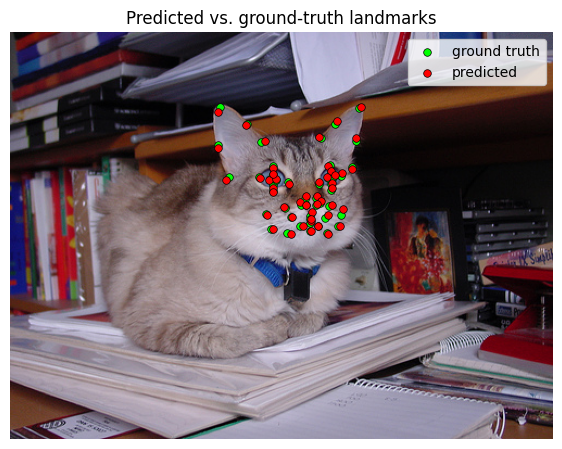

In [8]:
# Figure 1
if not HAS_CATFLW:
    print("Skipping figure 1 because it requires dataset.")
else:
    model = load_trained("resnet18")
    to_tensor = T.ToTensor()

    sample_label = test_files[0]
    with open(os.path.join(label_dir, sample_label)) as f:
        ann = json.load(f)

    gt = np.array(ann["labels"], dtype=np.float32)
    x_min, y_min, x_max, y_max = map(int, ann["bounding_boxes"])
    crop_w, crop_h = x_max - x_min, y_max - y_min

    img = cv2.cvtColor(cv2.imread(find_matching_image(sample_label, image_dir)), cv2.COLOR_BGR2RGB)
    crop = cv2.resize(img[y_min:y_max, x_min:x_max], (224, 224))
    with torch.no_grad():
        pred_norm = model(to_tensor(crop).unsqueeze(0).to(device)).cpu().view(-1,2).numpy()

    pred_px = pred_norm.copy()
    pred_px[:,0] = pred_px[:,0] * crop_w + x_min
    pred_px[:,1] = pred_px[:,1] * crop_h + y_min

    plt.figure(figsize=(7,7))
    plt.imshow(img)
    plt.scatter(gt[:,0], gt[:,1], c="lime", s=30, label="ground truth", edgecolors="black", linewidths = 0.5)
    plt.scatter(pred_px[:,0], pred_px[:,1], c="red", s=30, label="predicted", edgecolors="black", linewidths = 0.5)
    plt.legend(loc="upper right")
    plt.axis("off")
    plt.title("Predicted vs. ground-truth landmarks")
    plt.show()

## 7.2 Overfitting analysis

Produces Table 3 (train-set NME vs test-set NME) and Figure 2 (training and validation loss curve).   

In [9]:
results_72={}

if "get_model" not in globals() or not results_71:
    print(
        "Skipping train/test NME gap because CatFLW-dependent setup "
        "or test NME results are not available."
    )
else:
    for arch in ARCHS:
        if arch not in results_71:
            print(
                f"{arch:20s}   skipping train/test gap because no testNME is available "
                "(checkpoint missing or skipped earlier)."
            )
            continue

        model=load_trained(arch)
        tr=evaluate_nme(model, train_files, image_dir, label_dir, device)["overall"]
        te = results_71[arch]["overall"]
        results_72[arch] = (tr, te, te - tr)

print(f"{'Model':20s}{'Train NME':>12s}{'Test NME':>12s}{'Gap':>10s}")
print("-" * 60)
for arch in ARCHS:
    if arch not in results_72:
        print(f"{arch:20s}{'checkpoint missing':>12s}{'-':>12s}{'-':>10s}")
        continue
    
    tr, te, gap = results_72[arch]
    print(f"{arch:20s}{tr:>11.3f}%{te:>11.3f}%{gap:>9.3f}%")

Model                  Train NME    Test NME       Gap
------------------------------------------------------------
resnet18                  0.753%      1.266%    0.513%
resnet50                  0.574%      1.396%    0.821%
efficientnet_b0           2.040%      2.276%    0.235%
mobilenet_v3_small        2.000%      2.332%    0.332%


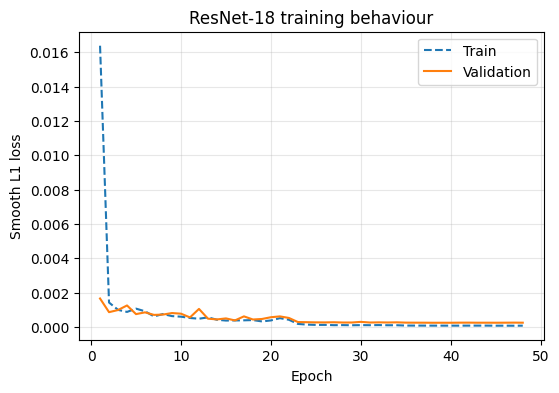

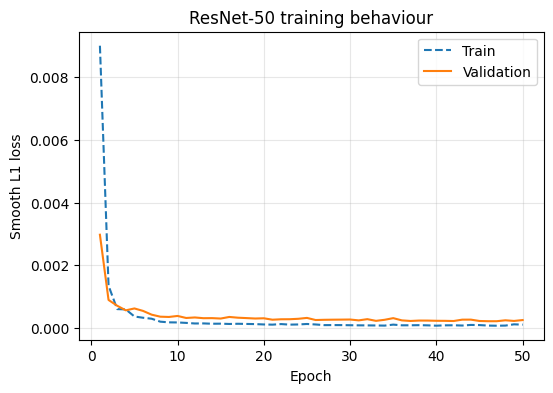

In [10]:
def plot_training_history(history_path, title):
    with history_path.open("r") as f:
        hist = json.load(f)
    
    plt.figure(figsize=(6, 4))
    plt.plot(hist["epoch"], hist["train_loss"], label="Train", linestyle = "--")
    plt.plot(hist["epoch"], hist["val_loss"], label="Validation")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Smooth L1 loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_training_history(HIST18_PATH, "ResNet-18 training behaviour")
plot_training_history(HIST50_PATH, "ResNet-50 training behaviour")


## 7.3 Geometric feature validation
Compares geometric features computed on CatFLW ground truth landmarks against the Evangelista et al. (2019) control/painful distributions. This is the table with the four features and z-scores vs the control mean

In [11]:
FEATURES = ["ear_tips_bases_ratio", "eye_height_width_ratio",
            "medial_ear_angle", "lateral_ear_angle"]

if not HAS_CATFLW:
    print("Skipping this cell because it requires CatFLW images/labels")

else:
    gt_values = {f: [] for f in FEATURES}
    for lf in all_label_files:
        with open(os.path.join(label_dir, lf)) as f:
            pts = np.array(json.load(f)["labels"], dtype=float)
        feats = compute_all_features(pts)
        for k, v in feats.items():
            if not (isinstance(v, float) and math.isnan(v)):
                gt_values[k].append(v)

    print(f"{'Feature':26s}{'CatFLW μ±σ':>18s}{'E.ctrl':>12s}{'E.pain':>12s}{'z vs. ctrl':>12s}")
    print("-" * 80)

    for f in FEATURES:
        arr = np.array(gt_values[f])
        mu, sd = arr.mean(), arr.std()
        s = EVANGELISTA_STATS[f]
        z = (mu - s["control_mean"])/s["control_sd"]
        print(f"{f:26s}{mu:>10.2f}±{sd:<5.2f}"
            f"{s['control_mean']:>8.2f}±{s['control_sd']:<3.2f}"
            f"{s['painful_mean']:>8.2f}±{s['painful_sd']:<3.2f}{z:>+11.2f}")

Feature                           CatFLW μ±σ      E.ctrl      E.pain  z vs. ctrl
--------------------------------------------------------------------------------
ear_tips_bases_ratio            2.72±0.44     2.85±0.30    2.34±0.30      -0.42
eye_height_width_ratio          0.76±0.15     0.79±0.10    0.50±0.20      -0.33
medial_ear_angle              131.73±8.35   126.50±4.70  140.40±6.50      +1.11
lateral_ear_angle              78.64±6.05    78.90±3.10   68.50±5.90      -0.08


## 7.4 Pain classification

End to end pipeline evaluation on the 40 hand-labelled feline pain/no-pain images. Also outputs the 4-class confusion matrix and the binary pain/no-pain confusion matrix/metrics.

In [12]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score, accuracy_score

if not HAS_CATFLW:
    print("Skipping this cell because it requires CatFLW images/labels")
    
else:
        
    with PASS1_PATH.open("r") as f:
        hand = json.load(f)

    model = load_trained("resnet18")
    to_tensor = T.ToTensor()

    y_true, y_pred = [], []
    skipped = 0
    for fname, entry in hand.items():
        if entry.get("excluded", False):
            skipped +=1
            continue
        
        lf = fname if fname.endswith(".json") else os.path.splitext(fname)[0] + ".json"
        with open(os.path.join(label_dir, lf)) as f:
            ann = json.load(f)
        x_min, y_min, x_max, y_max = map(int, ann["bounding_boxes"])
        crop_w, crop_h = x_max - x_min, y_max - y_min

        img = cv2.cvtColor(cv2.imread(find_matching_image(lf, image_dir)), cv2.COLOR_BGR2RGB)
        crop = cv2.resize(img[y_min:y_max, x_min:x_max], (224, 224))
        with torch.no_grad():
            pred_norm = model(to_tensor(crop).unsqueeze(0).to(device)).cpu().view(-1, 2).numpy()
        
        pred_px = pred_norm.copy()
        pred_px[:, 0] = pred_px[:, 0] * crop_w + x_min
        pred_px[:, 1] = pred_px[:, 1] * crop_h + y_min

        result = classify_landmarks(pred_px)
        y_true.append(entry["label"])
        y_pred.append(result["bucket"])

    acc = accuracy_score(y_true, y_pred)
    kappa_lin = cohen_kappa_score(y_true, y_pred, labels=BUCKETS, weights="linear")
    print(f"n={len(y_true)} (excluded={skipped}) accuracy={acc:.1%} linear-weighted κ={kappa_lin:.2f}")

n=40 (excluded=4) accuracy=57.5% linear-weighted κ=0.53


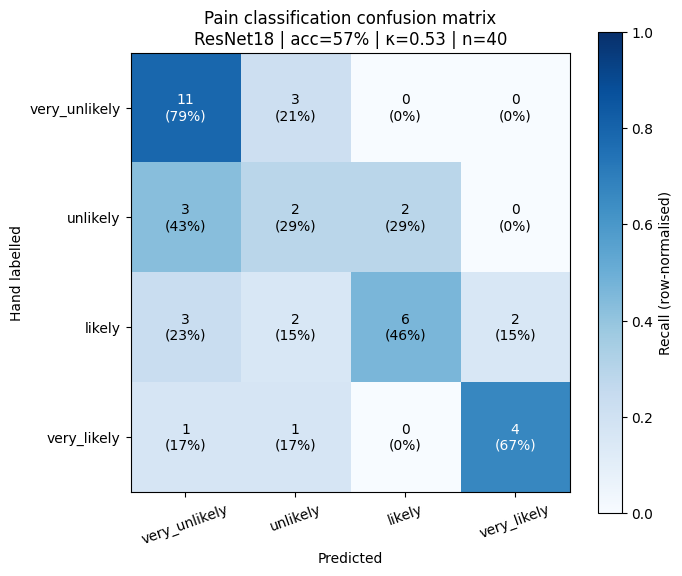

In [13]:
if "y_true" not in globals() or not y_true:
    print("Skipping confusion matrix because pred matrix not computed.")
else:
    cm = confusion_matrix(y_true, y_pred, labels=BUCKETS)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(4)); ax.set_xticklabels(BUCKETS, rotation=20)
    ax.set_yticks(range(4)); ax.set_yticklabels(BUCKETS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Hand labelled")
    ax.set_title(f"Pain classification confusion matrix\nResNet18 | acc={acc:.0%} | κ={kappa_lin:.2f} | n={len(y_true)}")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{cm[i, j]}\n({cm_norm[i, j]:.0%})",
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > 0.5 else "black")
    plt.colorbar(im, label="Recall (row-normalised)")
    plt.tight_layout(); plt.show()

In [14]:
def to_binary(b): return "pain" if b in ("likely", "very_likely") else "no_pain"

if "y_true" not in globals() or not y_true:
    print("Skipping because pred metrics not computed.")
else:
    yt_bin = [to_binary(b) for b in y_true]
    yp_bin = [to_binary(b) for b in y_pred]

    cm_bin = confusion_matrix(yt_bin, yp_bin, labels=["no_pain", "pain"])
    tn, fp, fn, tp = cm_bin.ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    acc_bin = (tp + tn) / cm_bin.sum()
    kappa_bin = cohen_kappa_score(yt_bin, yp_bin)

    print(f"Binary accuracy: {acc_bin:.1%}")
    print(f"Cohen's κ: {kappa_bin:.2f}")
    print(f"Sensitivity: {sens:.1%}")
    print(f"Specificity: {spec:.1%}")
    print(f"\nConfusion matrix (rows=truth, cols=pred):")
    print(f"                pred no-pain     pred pain")
    print(f"no-pain         {tn:>10d}      {fp:>10d}")
    print(f"pain            {fn:>10d}      {tp:>10d}")

Binary accuracy: 77.5%
Cohen's κ: 0.54
Sensitivity: 63.2%
Specificity: 90.5%

Confusion matrix (rows=truth, cols=pred):
                pred no-pain     pred pain
no-pain                 19               2
pain                     7              12


In [ ]:
if not HAS_CATFLW or "hand" not in globals() or "model"  not in globals():
    print("Skipping because CatFLW not set up")
else:    
    per_feature_agree = {f: 0 for f in FEATURES}
    per_feature_total = {f: 0 for f in FEATURES}

    for fname, entry in hand.items():
        if entry.get("excluded", False):
            continue

        lf = fname if fname.endswith(".json") else os.path.splitext(fname)[0] + ".json"
        with open(os.path.join(label_dir, lf)) as f:
            ann = json.load(f)
        x_min, y_min, x_max, y_max = map(int, ann["bounding_boxes"])
        crop_w, crop_h = x_max - x_min, y_max - y_min

        img = cv2.cvtColor(cv2.imread(find_matching_image(lf, image_dir)), cv2.COLOR_BGR2RGB)
        crop = cv2.resize(img[y_min:y_max, x_min:x_max], (224, 224))
        with torch.no_grad():
            pred_norm = model(to_tensor(crop).unsqueeze(0).to(device)).cpu().view(-1, 2).numpy()

        pred_px = pred_norm.copy()
        pred_px[:, 0] = pred_px[:, 0] * crop_w + x_min
        pred_px[:, 1] = pred_px[:, 1] * crop_h + y_min
        
        feats = compute_all_features(pred_px)
        truth_bin = to_binary(entry["label"])

        for f in FEATURES:
            v = feats[f]
            if isinstance(v, float) and math.isnan(v):
                continue
            s = EVANGELISTA_STATS[f]
            z_ctrl = abs(v - s["control_mean"]) / s["control_sd"]
            z_pain = abs(v - s["painful_mean"]) / s["painful_sd"]
            vote = "pain" if z_pain < z_ctrl else "no_pain"

            per_feature_total[f] += 1
            if vote == truth_bin:
                per_feature_agree[f] += 1
            
    print(f"{'Feature':28s}{'Agreement':>25s}{'%':>10s}")
    print("-" * 52)
    for f in sorted(FEATURES, key=lambda x: -per_feature_agree[x] / per_feature_total[x]):
        n_agree = per_feature_agree[f]
        n_tot = per_feature_total[f]
        print(f"{f:28s}{n_agree:>4d}/{n_tot:<8d}{n_agree / n_tot:>9.1%}")


Feature                                     Agreement         %
----------------------------------------------------
eye_height_width_ratio        31/40          77.5%
ear_tips_bases_ratio          29/40          72.5%
lateral_ear_angle             26/40          65.0%
medial_ear_angle              24/40          60.0%


In [16]:
def interpret_kappa(k):
    if k < 0:
        return "poor"
    elif k <= 0.20:
        return "slight"
    elif k <= 0.40:
        return "fair"
    elif k <= 0.60:
        return "moderate"
    elif k <= 0.80:
        return "substantial"
    else:
        return "almost perfect"
    
def load_labels(path):
    with path.open("r") as f:
        return json.load(f)
    
def compare_raters(data_a, data_b, name_a="Rater A", name_b="Rater B"):
    # Comparing 2 label sets/printing kappa stats
    common = sorted(set(data_a.keys()) & set(data_b.keys()))
    y_a, y_b = [], []

    for fname in common:
        a = data_a[fname]
        b = data_b[fname]

        if a.get("excluded") or b.get("excluded"):
            continue
        if a.get("label") is None or b.get("label") is None:
            continue
        y_a.append(LABEL_TO_INT[a["label"]])
        y_b.append(LABEL_TO_INT[b["label"]])

    raw = accuracy_score(y_a, y_b)
    k_uw = cohen_kappa_score(y_a, y_b)
    k_lw = cohen_kappa_score(y_a, y_b, weights="linear")
    k_qw = cohen_kappa_score(y_a, y_b, weights="quadratic")
    cm = confusion_matrix(y_a, y_b, labels=range(len(BUCKETS)))

    print(f"\n{name_a} vs {name_b}")
    print("=" * 50)
    print(f"Compared images:                    {len(y_a)}")
    print(f"Raw agreement:                      {raw:.1%}")
    print(f"Cohen's kappa (unweighted):         {k_uw:.3f}")
    print(f"Cohen's kappa (linear weighted):    {k_lw:.3f}")
    print(f"Cohen's kappa (quadratic wt):       {k_qw:.3f}")
    print(f"\nConfusion matrix (rows={name_a}, cols={name_b})")
    print(f"Labels:   {BUCKETS}")
    print(cm)

    return {
        "n": len(y_a),
        "raw": raw,
        "kappa_unweighted": k_uw,
        "kappa_lw": k_lw,
        "kappa_qw": k_qw,
        "confusion_matrix": cm,
    }

p1 = load_labels(PASS1_PATH)
p2 = load_labels(PASS2_PATH)
r2 = load_labels(RATER2_PATH)

#intra-rater (pass 1 vs pass 2)
intra = compare_raters(p1, p2, "Pass 1", "Pass 2")
only_in_p1 = sorted(set(p1.keys()) - set(p2.keys()))
only_in_p2 = sorted(set(p2.keys()) - set(p1.keys()))
print(f"\nOnly in pass 1: {len(only_in_p1)}")
print(f"Only in pass 2: {len(only_in_p2)}")

print(f"Interpretation (linear weighted): {interpret_kappa(intra['kappa_lw'])} agreement")

#inter rated (pass 1 vs rater 2)
inter = compare_raters(p1, r2, "Pass 1 (author)", "Rater 2")
print(f"Interpretation (linear weighted): {interpret_kappa(inter['kappa_lw'])} agreement")

print("\n\nSummary:")
print("=" * 50)
print(f"Intra-rater κ (linear weighted): {intra['kappa_lw']:.3f}")
print(f"Inter-rater κ (linear weighted): {inter['kappa_lw']:.3f}")
if "kappa_lin" in globals():
    print(f"Pipeline vs rater κ:             {kappa_lin:.2f}")
    print("\n Expected ordering: intra ≥ inter ≥ pipeline")
else:
        print(f"Pipeline vs rater κ:             skipped due to lack of CatFLW/model prediction metrics")



Pass 1 vs Pass 2
Compared images:                    40
Raw agreement:                      60.0%
Cohen's kappa (unweighted):         0.441
Cohen's kappa (linear weighted):    0.607
Cohen's kappa (quadratic wt):       0.746

Confusion matrix (rows=Pass 1, cols=Pass 2)
Labels:   ['very_unlikely', 'unlikely', 'likely', 'very_likely']
[[11  3  0  0]
 [ 4  3  0  0]
 [ 1  4  8  0]
 [ 0  1  3  2]]

Only in pass 1: 4
Only in pass 2: 0
Interpretation (linear weighted): substantial agreement

Pass 1 (author) vs Rater 2
Compared images:                    40
Raw agreement:                      62.5%
Cohen's kappa (unweighted):         0.496
Cohen's kappa (linear weighted):    0.667
Cohen's kappa (quadratic wt):       0.806

Confusion matrix (rows=Pass 1 (author), cols=Rater 2)
Labels:   ['very_unlikely', 'unlikely', 'likely', 'very_likely']
[[9 4 1 0]
 [2 5 0 0]
 [0 3 7 3]
 [0 0 2 4]]
Interpretation (linear weighted): substantial agreement


Summary:
Intra-rater κ (linear weighted): 0.607
Inter

## 7.5 Error analysis

In [17]:
if not HAS_CATFLW:
    print("Skipping this cell because it requires CatFLW images/labels")
    
else:
    model = load_trained("resnet18")
    to_tensor = T.ToTensor()

    gt_feat = {f: [] for f in FEATURES}
    pr_feat = {f: [] for f in FEATURES}

    for lf in test_files:
        with open(os.path.join(label_dir, lf)) as f:
            ann = json.load(f)
        gt_pts = np.array(ann["labels"], dtype=float)
        x_min, y_min, x_max, y_max = map(int, ann["bounding_boxes"])
        crop_w, crop_h = x_max - x_min, y_max - y_min
        if crop_w <= 0 or crop_h <= 0:
            continue

        img = cv2.cvtColor(cv2.imread(find_matching_image(lf, image_dir)), cv2.COLOR_BGR2RGB)
        crop = cv2.resize(img[y_min:y_max, x_min:x_max], (224, 224))
        with torch.no_grad():
            pn = model(to_tensor(crop).unsqueeze(0).to(device)).cpu().view(-1, 2).numpy()
        pr_pts = pn.copy()
        pr_pts[:,0]=pr_pts[:,0]*crop_w+x_min
        pr_pts[:,1]=pr_pts[:,1]*crop_h+y_min

        for k, v in compute_all_features(gt_pts).items():
            if not (isinstance(v, float) and math.isnan(v)): gt_feat[k].append(v)
        for k, v in compute_all_features(pr_pts).items():
            if not (isinstance(v, float) and math.isnan(v)): pr_feat[k].append(v)

    print(f"{'Feature':26s}{'GT μ':>10s}{'GT σ':>10s}{'Pred μ':>10s}{'Pred σ':>10s}{'Δ mean':>10s}")
    print("-"*76)
    for f in FEATURES:
        g = np.array(gt_feat[f]); p = np.array(pr_feat[f])
        print(f"{f:26s}{g.mean():>10.3f}{g.std():>10.3f}"
        f"{p.mean():>10.3f}{p.std():>10.3f}{p.mean()-g.mean():>+10.3f}")
        

Feature                         GT μ      GT σ    Pred μ    Pred σ    Δ mean
----------------------------------------------------------------------------
ear_tips_bases_ratio           2.732     0.439     2.665     0.311    -0.067
eye_height_width_ratio         0.757     0.145     0.756     0.128    -0.002
medial_ear_angle             131.683     7.954   131.007     6.801    -0.676
lateral_ear_angle             78.643     6.302    79.233     3.620    +0.590
